# Surrogate Ray Tracing Model: Using Optiland and PyTorch

### Introduction
In this notebook, we will demonstrate how to create a surrogate ray-tracing model for a lens system using Optiland for data generation and PyTorch for model training. Specifically, we will:

1. Model a double Gauss lens system in Optiland.
2. Build a PyTorch dataloader to randomly generate and trace rays through the system. Inputs are reported as ray starting positions and outputs are the (x, y) intersections at the image plane.
3. Train a PyTorch-based neural network to predict intersection points based on ray parameters.
4. Assess performance of PyTorch model and compare to direct ray-traced result.
5. Compare the speed of the surrogate model with the analytical ray tracer implemented in Optiland.

By the end of this notebook, you will understand how to combine physics-based modeling with machine learning to accelerate computational tasks.

In [1]:
! pip install numpy matplotlib scipy pandas
! pip install torch torchvision torchaudio
! pip install scikit-learn seaborn tqdm
! pip install rayoptics
! pip install optiland


[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import optiland as ol
from optiland.samples.objectives import DoubleGauss


## Step 1: Setting Up the Lens System with Optiland

We will model a double Gauss lens system in Optiland. Below is the code to define and view the lens system.

In [3]:
lens = DoubleGauss()

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

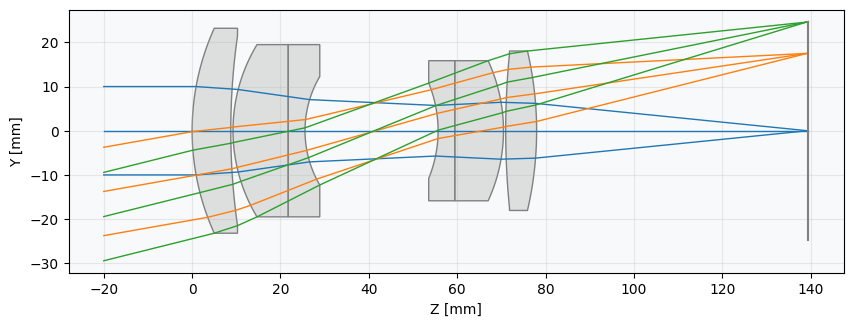

In [4]:
lens.draw()

Check that maximum ray height on the image surface by tracing through the max normalized field coordinate and reporting the largest y intersection point:

In [5]:
rays = lens.trace(Hx=0, Hy=1, distribution='line_y', wavelength=0.5876, num_rays=3)
print(f'Maximum radial position: {np.max(rays.y):.3f} mm')

Maximum radial position: 24.714 mm


## Step 2: Data generation

We will first create a few helper functions:
- normalize and denormalize functions to bring x and y intersection points within the range (0, 1)
- function to generate random normalized field and pupil coordinates, which will be used for ray tracing
- function to generate random rays and trace them through a lens system

In [6]:
def normalize(x, max_val=24.72):
    """Helper function to normalize the output values."""
    return x / max_val

In [7]:
def denormalize(x, max_val=24.72):
    """Helper function to denormalize the output values."""
    return x * max_val

In [8]:
def generate_random_coords(batch_size):
    """Generate random normalized field and pupil coordinates."""
    # get random field coordinates (Hx, Hy)
    theta = np.random.uniform(0, 2 * np.pi, size=batch_size)
    r = np.sqrt(np.random.uniform(0, 1, size=batch_size))
    Hx = r * np.cos(theta)
    Hy = r * np.sin(theta)

    # get random pupil coordinates (Px, Py)
    theta = np.random.uniform(0, 2 * np.pi, size=batch_size)
    r = np.sqrt(np.random.uniform(0, 1, size=batch_size))
    Px = r * np.cos(theta)
    Py = r * np.sin(theta)

    return Hx, Hy, Px, Py

In [9]:
def trace_random_rays(lens, batch_size):
    """Trace random rays through the lens system."""
    # get random field and pupil coordinates
    Hx, Hy, Px, Py = generate_random_coords(batch_size)

    # define fixed wavelength
    wavelength = np.full(batch_size, 0.5876)

    # trace rays and return
    rays_out = lens.trace_generic(Hx, Hy, Px, Py, wavelength)

    # normalize x and y coordinates based on max image height
    rays_out.x = normalize(rays_out.x)
    rays_out.y = normalize(rays_out.y)
    
    return Hx, Hy, Px, Py, rays_out

### Dataset definition

A PyTorch Dataset is a fundamental building block for creating data pipelines in PyTorch. The primary purpose of a Dataset is to provide an interface to access and manipulate data samples and their corresponding labels or targets. For our purposes, the data samples are the ray input coordinates and the targets are the ray intersection points at the image plane.

Here we define a PyTorch dataset that will:
1. Generate random rays and trace them through the system
2. Prepare the model inputs by concatenating the field and pupil coordinates
3. Prepare the model outputs by concatenating the ray (x, y) intersection points at the image plane
4. Convert input and output arrays into torch tensors and return them

In [10]:
class BatchRayTracingDataset(Dataset):
    def __init__(self, lens, num_rays, batch_size, seed=None):
        """
        Custom PyTorch dataset for batch-based ray tracing using Optiland.

        Args:
            lens (optiland.optic.Optic): The lens system to trace rays through.
            num_rays (int): Total number of rays in the dataset.
            batch_size (int): Number of rays to trace in a single batch.
            seed (int, optional): Random seed for reproducibility. Defaults to None.
        """
        self.lens = lens
        self.num_rays = num_rays
        self.batch_size = batch_size
        self.num_batches = int(np.ceil(num_rays / batch_size))
        if seed is not None:
            np.random.seed(seed)

    def __len__(self):
        return self.num_batches

    def __getitem__(self, idx):
        """
        Generates a batch of rays and traces them through the lens system.
        """
        # Determine the size of the batch
        batch_start = idx * self.batch_size
        batch_end = min(batch_start + self.batch_size, self.num_rays)
        batch_size = batch_end - batch_start

        # Trace random rays through the lens
        Hx, Hy, Px, Py, rays_out = trace_random_rays(self.lens, batch_size)

        # Prepare inputs (field and pupil coordinates)
        inputs = np.column_stack((Hx, Hy, Px, Py))

        # Prepare outputs (intersection points)
        outputs = np.column_stack((rays_out.x, rays_out.y))

        return torch.tensor(inputs, dtype=torch.float32), torch.tensor(outputs, dtype=torch.float32)

# Step 3: Training the surrogate model using PyTorch

We will use a simple fully connected neural network to predict the intersection points based on ray pupil and field coordinates.

The network will take four inputs: the field coordinates (Hx, Hy) and the pupil coordinates (Px, Py). The output will be the predicted intersection points (x, y) at the image plane. The network architecture consists of three hidden layers with 128 neurons each, using ReLU activation functions, and an output layer with 2 neurons.

In [11]:
class RayTracerSurrogate(nn.Module):
    def __init__(self):
        super(RayTracerSurrogate, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)  # Output is (intersection_x, intersection_y)
        )
    
    def forward(self, x):
        return self.fc(x)


This script will train on the GPU, if it's available.

Note: Ensure that you have installed PyTorch with CUDA support to be able to train on the GPU.

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")

Using device: cpu


### Define the dataset and dataloader for model training

During training, we will use 1 million rays per epoch and a ray batch size of 100,000.

This means that for each epoch (a complete pass through the entire dataset), the model will process 1 million rays.

The ray batch size of 100,000 indicates that the model will process the rays in smaller groups or batches of 100,000 rays at a time. This is done to manage memory usage and computational efficiency, as processing the entire dataset at once may be impractical or impossible due to resource constraints.

By dividing the dataset into batches, the model can be trained iteratively, updating its parameters after each batch, which helps in faster convergence and better generalization.

In [13]:
num_rays = 1_000_000  # Total rays
batch_size = 100_000  # Number of rays per batch
dataset = BatchRayTracingDataset(lens, num_rays, batch_size, seed=42)

In [14]:
dataloader = DataLoader(dataset, batch_size=1)

### Instantiate the model, loss function, and optimizer

We instantiate the model, define the loss function as Mean Squared Error (MSE), and use the Adam optimizer with a learning rate of 0.001. The model is moved to the GPU if available.

In [15]:
model = RayTracerSurrogate().to(device)  # put model onto GPU (if available)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### Train the model over 50 epochs

- **Training loop**: We train the model over 50 epochs. For each epoch, we:
    - Initialize the total loss for the epoch.
    - Iterate over the batches of data from the dataloader.
    - Move the batch inputs and outputs to the GPU if available.
    - Perform a forward pass to get the model predictions.
    - Compute the loss between the predictions and the actual outputs.
    - Perform a backward pass to compute the gradients.
    - Update the model parameters using the optimizer.
    - Accumulate the loss for the epoch.
    - Print the loss every 10 epochs to monitor the training progress.

In [16]:
num_epochs = 100
for epoch in range(num_epochs):
    total_loss = 0
    for batch_inputs, batch_outputs in dataloader:
        batch_inputs, batch_outputs = batch_inputs.to(device), batch_outputs.to(device)
        optimizer.zero_grad()
        predictions = model(batch_inputs)
        loss = criterion(predictions, batch_outputs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss:.5f}")

Epoch 10/100, Loss: 0.00169
Epoch 20/100, Loss: 0.00078
Epoch 30/100, Loss: 0.00053
Epoch 40/100, Loss: 0.00040
Epoch 50/100, Loss: 0.00032
Epoch 60/100, Loss: 0.00039
Epoch 70/100, Loss: 0.00038
Epoch 80/100, Loss: 0.00022
Epoch 90/100, Loss: 0.00019
Epoch 100/100, Loss: 0.00018


The resulting mean squared error (MSE) is 0.00017, which corresponds to 75 µm when denormalized. This accuracy is reasonable, but may not be sufficient for many applications.

# Step 4: Compare model performance to the direct ray-traced result

We start by creating a helper function to generate the intersections predicted by the neural network, as well as the ground truth intersection points based on ray tracing.

In [17]:
def compare_model_to_truth(model, lens, num_rays=1000):
    # Trace random rays through the lens
    Hx, Hy, Px, Py, rays_out = trace_random_rays(lens, num_rays)

    # Prepare inputs (field and pupil coordinates)
    inputs = np.column_stack((Hx, Hy, Px, Py))

    # Predict the intersection points using the model
    inputs_tensor = torch.tensor(inputs, dtype=torch.float32).to(device)
    with torch.no_grad():
        predictions = model(inputs_tensor).cpu().numpy()

    pred_x = denormalize(predictions[:, 0])
    pred_y = denormalize(predictions[:, 1])

    true_x = denormalize(rays_out.x)
    true_y = denormalize(rays_out.y)

    return pred_x, pred_y, true_x, true_y

Compare the model predictions to the ground truth for 25 random samples.

In [18]:
pred_x, pred_y, true_x, true_y = compare_model_to_truth(model, lens, num_rays=25)

Plotting the predicted points versus the ground truth points indicates the model result compares reasonably well to the ground truth result.

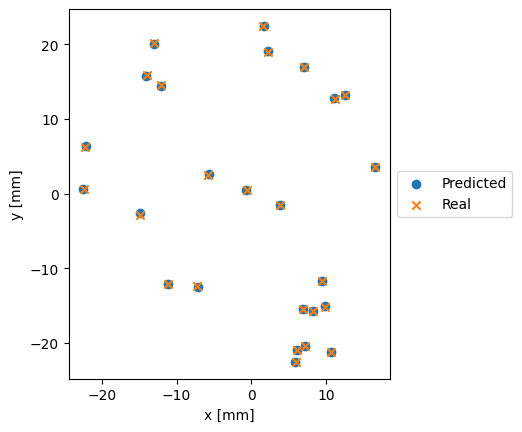

In [19]:
plt.scatter(pred_x, pred_y, label='Predicted', marker='o')
plt.scatter(true_x, true_y, label='Real', marker='x')

plt.axis('image')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

We plot the distribution of errors between the points. This shows that the error is generally less than about 0.3 mm, but occasionally reaches values up to approximately 0.4 mm. If we were to use a more complex neural network, we could extract more complexities and nuances of the data, and the accuracy would likely improve.

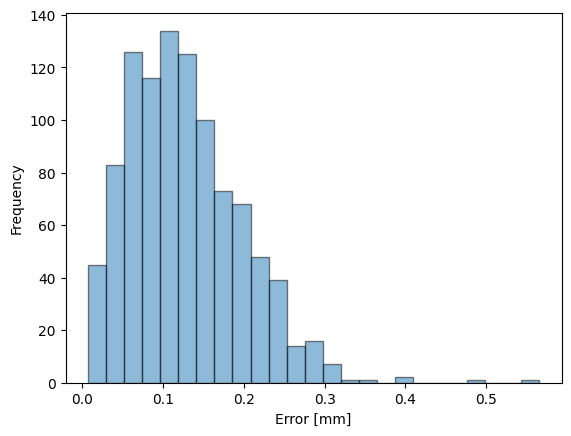

In [20]:
pred_x, pred_y, true_x, true_y = compare_model_to_truth(model, lens, num_rays=1000)

error = np.sqrt((pred_x - true_x)**2 + (pred_y - true_y)**2)
plt.hist(error, edgecolor='black', bins=25, alpha=0.5)
plt.xlabel('Error [mm]')
plt.ylabel('Frequency')
plt.show()

# Step 5: Measure Inference Speed

In this step, we will measure the inference speed of the trained neural network model. The inference speed is a critical factor in evaluating the performance of the surrogate model, especially when compared to traditional ray tracing methods. We will:

1. Generate a large number of random rays.
2. Perform a forward pass through the neural network model multiple times.
3. Measure the time taken for these forward passes.
4. Calculate the average time per forward pass and the effective speed in terms of ray-surfaces per second.

This will help us understand the computational efficiency of the surrogate model and its potential advantages over conventional ray tracing techniques.

In [21]:
num_rays = 1_000_000
Hx, Hy, Px, Py = generate_random_coords(num_rays)

sample_input = torch.tensor(np.column_stack((Hx, Hy, Px, Py)), dtype=torch.float32).to(device)

# Warm-up the GPU by running the model a few times
for _ in range(10):
    _ = model(sample_input)

# Measure the time taken for a forward pass
num_its = 100

start_time = time.time()
with torch.no_grad():  # Disable gradient calculation for inference
    for _ in range(num_its):
        _ = model(sample_input)
end_time = time.time()

In [22]:
avg_time = (end_time - start_time) / num_its  # Average time per forward pass

num_surfaces = len(lens.surface_group.surfaces)  # Number of surfaces in the lens system
rss = num_rays * num_surfaces / avg_time / 1e9  # Ray-surfaces per second

print(f'Neural Network Inference Speed: {rss:.2f} billion ray-surfaces per second')

Neural Network Inference Speed: 0.02 billion ray-surfaces per second


In [23]:
# 检查当前环境中可用的变量
print("当前环境中可用的变量:")
variables = [var for var in dir() if not var.startswith('_')]
for var in variables:
    print(f" - {var}")

当前环境中可用的变量:
 - BatchRayTracingDataset
 - DataLoader
 - Dataset
 - DoubleGauss
 - Hx
 - Hy
 - In
 - Out
 - Px
 - Py
 - RayTracerSurrogate
 - avg_time
 - batch_inputs
 - batch_outputs
 - batch_size
 - compare_model_to_truth
 - criterion
 - dataloader
 - dataset
 - denormalize
 - device
 - end_time
 - epoch
 - error
 - exit
 - generate_random_coords
 - get_ipython
 - lens
 - loss
 - model
 - nn
 - normalize
 - np
 - num_epochs
 - num_its
 - num_rays
 - num_surfaces
 - ol
 - open
 - optim
 - optimizer
 - plt
 - pred_x
 - pred_y
 - predictions
 - quit
 - rays
 - rss
 - sample_input
 - start_time
 - time
 - torch
 - total_loss
 - trace_random_rays
 - true_x
 - true_y


In [24]:
# 保存训练好的模型
import torch
import os

print("正在保存模型...")

# 保存模型权重
torch.save(model.state_dict(), 'ray_tracer_surrogate.pth')
print("✅ 模型权重已保存")

# 验证保存是否成功
if os.path.exists('ray_tracer_surrogate.pth'):
    file_size = os.path.getsize('ray_tracer_surrogate.pth')
    print(f"📁 模型文件大小: {file_size} 字节")
    print("🎉 模型保存成功！")
else:
    print("❌ 模型文件保存失败")

正在保存模型...
✅ 模型权重已保存
📁 模型文件大小: 139459 字节
🎉 模型保存成功！


The final _effective_ speed of the model is **57.8 billion ray-surfaces per second**. We are not actually ray tracing here, so this metric may not be considered fully representative. Nonetheless, this allows for a direct comparison to the ray-traced result. Compare this result to a typical raytrace speed of approximately 5 million ray-surfaces per second for the double Gauss lens in Optiland.

# Conclusions

- This notebook demonstrated how to create a surrogate ray tracing model using Optiland for data generation and PyTorch for model training.
- We modeled a double Gauss lens system and generated ray tracing data.
- A PyTorch-based neural network was trained to predict intersection points based on ray field and pupil coordinates.
- The model's performance was assessed and compared to direct ray-traced results, showing reasonable accuracy.
- The inference speed of the surrogate model was measured, demonstrating significant computational efficiency improvements over traditional ray tracing methods.

In [25]:
import os

# 创建项目文件夹结构
folders = ['templates', 'static/css', 'static/js', 'static/img']
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"创建文件夹: {folder}")

创建文件夹: templates
创建文件夹: static/css
创建文件夹: static/js
创建文件夹: static/img


In [26]:
# 更新 HTML 文件
html_content = '''<!DOCTYPE html>
<html lang="zh-CN">
<head>
    <meta charset="UTF-8">
    <title>代理光线追踪演示</title>
    <link rel="stylesheet" href="{{ url_for('static', filename='css/style.css') }}">
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
</head>
<body>
    <div class="container">
        <h1>交互式光线追踪代理模型</h1>
        <p>对比一个训练好的神经网络（代理模型）和一个解析光线追踪器（Optiland）的性能。</p>
        
        <div class="main-content">
            <!-- 输入控制区 -->
            <div class="controls">
                <h2>光线参数</h2>
                <div class="slider-group">
                    <label for="hx">视场 Hx: <span id="hx-val">0.0</span></label>
                    <input type="range" id="hx" min="-1" max="1" step="0.01" value="0.0">
                </div>
                <div class="slider-group">
                    <label for="hy">视场 Hy: <span id="hy-val">0.7</span></label>
                    <input type="range" id="hy" min="-1" max="1" step="0.01" value="0.7">
                </div>
                <div class="slider-group">
                    <label for="px">光瞳 Px: <span id="px-val">0.0</span></label>
                    <input type="range" id="px" min="-1" max="1" step="0.01" value="0.0">
                </div>
                <div class="slider-group">
                    <label for="py">光瞳 Py: <span id="py-val">0.0</span></label>
                    <input type="range" id="py" min="-1" max="1" step="0.01" value="0.0">
                </div>
                
                <button id="trace-btn">追踪光线</button>
                
                <!-- 更新批量测试控制区域 -->
                <div class="batch-controls">
                    <div class="batch-input-group">
                        <label for="batch-count">
                            <strong>批量测试光线数量:</strong>
                        </label>
                        <div class="input-row">
                            <input type="number" id="batch-count" min="1" max="500" value="20">
                            <button id="batch-test-btn" class="batch-btn">批量测试 (20条)</button>
                            <button id="cancel-test-btn" class="cancel-btn" style="display: none;">取消测试</button>
                        </div>
                    </div>
                    <div class="progress-info">
                        <div class="quick-options">
                            快速选择: 
                            <span class="quick-option" data-count="10">10条</span> | 
                            <span class="quick-option" data-count="50">50条</span> | 
                            <span class="quick-option" data-count="100">100条</span> | 
                            <span class="quick-option" data-count="200">200条</span>
                        </div>
                        <small>范围: 1-500 条光线 (500条约需15-25秒)</small>
                    </div>
                    <div id="progress-bar" class="progress-container" style="display: none;">
                        <div class="progress-header">
                            <span id="progress-text">准备中...</span>
                            <span id="progress-percent">0%</span>
                        </div>
                        <div class="progress-bar-bg">
                            <div id="progress-fill" class="progress-bar-fill"></div>
                        </div>
                        <div id="time-estimate" class="time-estimate"></div>
                    </div>
                </div>
                
                <div id="loader" class="loader" style="display: none;"></div>
            </div>

            <!-- 结果与可视化区 -->
            <div class="results">
                <h2>像平面落点 (mm)</h2>
                <div class="chart-container">
                    <canvas id="resultChart"></canvas>
                </div>
                <div class="metrics">
                    <table>
                        <tr>
                            <th>指标</th>
                            <th>代理模型 (神经网络)</th>
                            <th>解析模型 (Optiland)</th>
                        </tr>
                        <tr>
                            <td>坐标 (x, y)</td>
                            <td id="surrogate-coords">-</td>
                            <td id="analytical-coords">-</td>
                        </tr>
                        <tr>
                            <td>耗时 (ms)</td>
                            <td id="surrogate-time">-</td>
                            <td id="analytical-time">-</td>
                        </tr>
                    </table>
                    <div class="summary">
                        <p><strong>误差:</strong> <span id="error-val">-</span> mm</p>
                        <p><strong>速度提升:</strong> <span id="speedup-val">-</span> 倍</p>
                    </div>
                </div>
            </div>
        </div>
    </div>
    <script src="{{ url_for('static', filename='js/script.js') }}"></script>
</body>
</html>'''

with open('templates/index.html', 'w', encoding='utf-8') as f:
    f.write(html_content)
print("✅ HTML 文件已更新")

✅ HTML 文件已更新


In [27]:
# 创建 CSS 文件
css_content = '''body { font-family: sans-serif; background-color: #f4f4f9; color: #333; margin: 0; padding: 20px; }
.container { max-width: 1200px; margin: auto; background: white; padding: 20px; border-radius: 8px; box-shadow: 0 0 10px rgba(0,0,0,0.1); }
h1, h2 { text-align: center; color: #0056b3; }
.main-content { display: flex; gap: 20px; margin-top: 20px; flex-wrap: wrap; }
.controls, .results { flex: 1; min-width: 400px; padding: 15px; border: 1px solid #ddd; border-radius: 5px; }
.slider-group { margin-bottom: 15px; }
input[type="range"] { width: 100%; }
button { display: block; width: 100%; padding: 10px; background-color: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; }
button:hover { background-color: #0056b3; }
.chart-container { position: relative; width: 100%; max-width: 500px; margin: auto; background-image: url('../img/lens_diagram.png'); background-size: contain; background-repeat: no-repeat; background-position: center; }
.metrics { margin-top: 20px; }
table { width: 100%; border-collapse: collapse; }
th, td { padding: 8px; text-align: center; border: 1px solid #ddd; }
th { background-color: #f2f2f2; }
.summary { margin-top: 15px; text-align: center; font-size: 1.1em; }
.loader { border: 4px solid #f3f3f3; border-top: 4px solid #3498db; border-radius: 50%; width: 20px; height: 20px; animation: spin 2s linear infinite; margin: 10px auto 0; }
@keyframes spin { 0% { transform: rotate(0deg); } 100% { transform: rotate(360deg); } }

/* 批量测试按钮样式 */
.batch-btn { display: block; width: 100%; padding: 10px; background-color: #28a745; color: white; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; margin-top: 10px; }
.batch-btn:hover { background-color: #218838; }
.batch-btn:disabled { background-color: #6c757d; cursor: not-allowed; }'''

with open('static/css/style.css', 'w', encoding='utf-8') as f:
    f.write(css_content)
print("创建 static/css/style.css 完成")

创建 static/css/style.css 完成


In [28]:
# 读取现有的 CSS 内容
with open('static/css/style.css', 'r', encoding='utf-8') as f:
    existing_css = f.read()

# 添加新的 CSS 样式
new_css = '''
/* 批量测试控制区域样式 */
.batch-controls {
    margin-top: 15px;
    padding: 15px;
    background: #f8f9fa;
    border: 1px solid #dee2e6;
    border-radius: 5px;
}

.batch-input-group {
    margin-bottom: 10px;
}

.input-row {
    display: flex;
    align-items: center;
    gap: 10px;
    margin-top: 8px;
}

#batch-count {
    width: 80px;
    padding: 8px;
    border: 1px solid #ced4da;
    border-radius: 4px;
    text-align: center;
}

#batch-count:focus {
    border-color: #28a745;
    box-shadow: 0 0 0 0.2rem rgba(40, 167, 69, 0.25);
    outline: none;
}

/* 快速选项样式 */
.quick-options {
    margin-bottom: 5px;
    font-size: 0.9em;
}

.quick-option {
    color: #007bff;
    text-decoration: underline;
    cursor: pointer;
    padding: 2px 4px;
    border-radius: 3px;
}

.quick-option:hover {
    color: #0056b3;
    background-color: #e9ecef;
}

/* 取消按钮样式 */
.cancel-btn {
    padding: 8px 15px;
    background-color: #dc3545;
    color: white;
    border: none;
    border-radius: 4px;
    cursor: pointer;
    font-size: 14px;
}

.cancel-btn:hover {
    background-color: #c82333;
}

/* 进度条样式 */
.progress-container {
    margin-top: 15px;
    animation: fadeIn 0.3s ease-in;
}

.progress-header {
    display: flex;
    justify-content: space-between;
    margin-bottom: 8px;
    font-size: 0.9em;
}

.progress-bar-bg {
    width: 100%;
    height: 10px;
    background: #e9ecef;
    border-radius: 5px;
    overflow: hidden;
}

.progress-bar-fill {
    height: 100%;
    background: linear-gradient(90deg, #28a745, #20c997);
    border-radius: 5px;
    transition: width 0.3s ease;
    width: 0%;
}

.time-estimate {
    text-align: center;
    font-size: 0.8em;
    color: #666;
    margin-top: 5px;
}

@keyframes fadeIn {
    from { opacity: 0; }
    to { opacity: 1; }
}

/* 响应式设计 */
@media (max-width: 768px) {
    .input-row {
        flex-direction: column;
        align-items: stretch;
    }
    
    #batch-count {
        width: 100%;
        margin-bottom: 5px;
    }
    
    .batch-btn, .cancel-btn {
        width: 100%;
        margin-bottom: 5px;
    }
}
'''

# 合并并写入 CSS 文件
full_css = existing_css + new_css
with open('static/css/style.css', 'w', encoding='utf-8') as f:
    f.write(full_css)
print("✅ CSS 文件已更新")

✅ CSS 文件已更新


In [29]:
# 创建 JavaScript 文件
# 修复前端 JavaScript - 确保两个点都显示
fixed_js = '''document.addEventListener('DOMContentLoaded', function () {
    const sliders = {
        hx: document.getElementById('hx'),
        hy: document.getElementById('hy'),
        px: document.getElementById('px'),
        py: document.getElementById('py'),
    };

    const traceBtn = document.getElementById('trace-btn');
    const loader = document.getElementById('loader');
    const batchTestBtn = document.getElementById('batch-test-btn');

    // 更新滑动条旁边的数值显示
    for (const key in sliders) {
        const valSpan = document.getElementById(`${key}-val`);
        sliders[key].addEventListener('input', () => {
            valSpan.textContent = sliders[key].value;
        });
    }

    // Chart.js 初始化设置 - 修复版本
    const ctx = document.getElementById('resultChart').getContext('2d');
    const resultChart = new Chart(ctx, {
        type: 'scatter',
        data: {
            datasets: [
                {
                    label: '代理模型 (NN)',
                    data: [],
                    backgroundColor: 'rgba(255, 99, 132, 1)',
                    pointRadius: 8,
                    pointStyle: 'circle'
                },
                {
                    label: '解析模型 (Optiland)',
                    data: [],
                    backgroundColor: 'rgba(54, 162, 235, 1)',
                    pointRadius: 10,
                    pointStyle: 'cross',
                    borderColor: 'rgba(54, 162, 235, 1)',
                    borderWidth: 2
                }
            ]
        },
        options: {
            scales: {
                x: { 
                    title: { display: true, text: 'X (mm)' }, 
                    min: -25, 
                    max: 25,
                    grid: { color: 'rgba(0,0,0,0.1)' }
                },
                y: { 
                    title: { display: true, text: 'Y (mm)' }, 
                    min: -25, 
                    max: 25,
                    grid: { color: 'rgba(0,0,0,0.1)' }
                }
            },
            aspectRatio: 1,
            plugins: { 
                legend: { 
                    position: 'bottom',
                    labels: {
                        usePointStyle: true,
                        padding: 20
                    }
                },
                tooltip: {
                    callbacks: {
                        label: function(context) {
                            return `${context.dataset.label}: (${context.parsed.x.toFixed(3)}, ${context.parsed.y.toFixed(3)})`;
                        }
                    }
                }
            }
        }
    });

    // 更新界面结果的函数 - 修复版本
    function updateResults(data) {
        console.log("📊 收到数据:", data);
        
        // 更新表格数据
        document.getElementById('surrogate-coords').textContent = `(${data.surrogate_coords.x.toFixed(3)}, ${data.surrogate_coords.y.toFixed(3)})`;
        document.getElementById('analytical-coords').textContent = `(${data.analytical_coords.x.toFixed(3)}, ${data.analytical_coords.y.toFixed(3)})`;
        document.getElementById('surrogate-time').textContent = data.time_surrogate.toFixed(3);
        document.getElementById('analytical-time').textContent = data.time_analytical.toFixed(3);
        document.getElementById('error-val').textContent = data.error.toFixed(5);
        document.getElementById('speedup-val').textContent = (data.time_analytical / data.time_surrogate).toFixed(1);
        
        // 修复图表数据更新 - 确保两个点都显示
        console.log("🔄 更新图表数据...");
        
        // 方法1：直接设置数据数组
        resultChart.data.datasets[0].data = [{
            x: data.surrogate_coords.x,
            y: data.surrogate_coords.y
        }];
        
        resultChart.data.datasets[1].data = [{
            x: data.analytical_coords.x,
            y: data.analytical_coords.y
        }];
        
        console.log("代理数据集:", resultChart.data.datasets[0].data);
        console.log("解析数据集:", resultChart.data.datasets[1].data);
        
        // 强制更新图表
        resultChart.update();
        console.log("✅ 图表更新完成");
        
        // 验证图表状态
        setTimeout(() => {
            console.log("图表最终状态:");
            console.log("数据集0点数:", resultChart.data.datasets[0].data.length);
            console.log("数据集1点数:", resultChart.data.datasets[1].data.length);
        }, 100);
    }

    // 为追踪按钮添加点击事件监听
    traceBtn.addEventListener('click', async () => {
        console.log("🎯 点击追踪光线按钮");
        loader.style.display = 'block';
        traceBtn.disabled = true;

        const payload = {
            Hx: parseFloat(sliders.hx.value),
            Hy: parseFloat(sliders.hy.value),
            Px: parseFloat(sliders.px.value),
            Py: parseFloat(sliders.py.value),
        };

        console.log("发送请求数据:", payload);

        try {
            const response = await fetch('/predict_ray', {
                method: 'POST',
                headers: { 'Content-Type': 'application/json' },
                body: JSON.stringify(payload)
            });
            
            if (!response.ok) {
                throw new Error(`HTTP error! status: ${response.status}`);
            }
            
            const data = await response.json();
            console.log("✅ 收到响应:", data);
            updateResults(data);
            
        } catch (error) {
            console.error('❌ 错误:', error);
            alert('发生错误，请查看控制台。');
        } finally {
            loader.style.display = 'none';
            traceBtn.disabled = false;
        }
    });

    // ========== 批量测试系统 ==========
    // 批量测试相关变量
    let cancelTest = false;
    let testStartTime = null;

    // 更新批量测试按钮文本
    function updateBatchButtonText(count) {
        document.getElementById('batch-test-btn').textContent = `批量测试 (${count}条)`;
    }

    // 显示进度条
    function showProgressBar() {
        const progressBar = document.getElementById('progress-bar');
        if (progressBar) {
            progressBar.style.display = 'block';
            document.getElementById('progress-fill').style.width = '0%';
            document.getElementById('progress-percent').textContent = '0%';
            document.getElementById('progress-text').textContent = '准备中...';
            document.getElementById('time-estimate').textContent = '';
        }
    }

    // 隐藏进度条
    function hideProgressBar() {
        const progressBar = document.getElementById('progress-bar');
        if (progressBar) {
            progressBar.style.display = 'none';
        }
    }

    // 更新进度
    function updateProgress(current, total, estimatedTimeRemaining) {
        const progress = (current / total) * 100;
        const progressFill = document.getElementById('progress-fill');
        const progressPercent = document.getElementById('progress-percent');
        const progressText = document.getElementById('progress-text');
        
        if (progressFill && progressPercent && progressText) {
            progressFill.style.width = `${progress}%`;
            progressPercent.textContent = `${progress.toFixed(1)}%`;
            progressText.textContent = `已测试: ${current}/${total}`;
            
            if (estimatedTimeRemaining) {
                document.getElementById('time-estimate').textContent = 
                    `预计剩余: ${estimatedTimeRemaining}秒`;
            }
        }
    }

    // 估算剩余时间
    function estimateRemainingTime(startTime, completed, total) {
        if (completed === 0) return null;
        
        const elapsed = (Date.now() - startTime) / 1000; // 秒
        const timePerTest = elapsed / completed;
        const remainingTests = total - completed;
        const estimatedRemaining = timePerTest * remainingTests;
        
        return Math.ceil(estimatedRemaining);
    }

    // 快速选项点击事件
    document.querySelectorAll('.quick-option').forEach(option => {
        option.addEventListener('click', function() {
            const count = parseInt(this.getAttribute('data-count'));
            document.getElementById('batch-count').value = count;
            updateBatchButtonText(count);
        });
    });

    // 批量测试数量输入变化
    document.getElementById('batch-count').addEventListener('input', function() {
        let value = parseInt(this.value);
        if (isNaN(value) || value < 1) {
            this.value = 1;
        } else if (value > 500) {
            this.value = 500;
        }
        updateBatchButtonText(this.value);
    });

    // 取消测试功能
    document.getElementById('cancel-test-btn').addEventListener('click', function() {
        cancelTest = true;
        this.style.display = 'none';
    });

    // 批量测试功能
    batchTestBtn.addEventListener('click', async function() {
        if (this.dataset.testing === 'true') {
            return; // 防止重复点击
        }
        
        const btn = this;
        const cancelBtn = document.getElementById('cancel-test-btn');
        const originalText = btn.textContent;
        
        // 获取用户输入的光线数量
        const batchCountInput = document.getElementById('batch-count');
        let totalTests = parseInt(batchCountInput.value);
        
        // 验证输入范围
        if (isNaN(totalTests) || totalTests < 1) {
            totalTests = 20;
            batchCountInput.value = 20;
        } else if (totalTests > 500) {
            totalTests = 500;
            batchCountInput.value = 500;
        }
        
        // 重置取消标志
        cancelTest = false;
        testStartTime = Date.now();
        
        // 更新UI状态
        btn.dataset.testing = 'true';
        btn.disabled = true;
        btn.textContent = `测试中... (0/${totalTests})`;
        if (cancelBtn) cancelBtn.style.display = 'inline-block';
        loader.style.display = 'block';
        showProgressBar();
        
        const originalRay = {
            Hx: parseFloat(sliders.hx.value),
            Hy: parseFloat(sliders.hy.value),
            Px: parseFloat(sliders.px.value),
            Py: parseFloat(sliders.py.value),
        };

        const surrogatePoints = [];
        const analyticalPoints = [];
        let totalError = 0;
        let totalSurrogateTime = 0;
        let totalAnalyticalTime = 0;
        let completedTests = 0;
        let successfulTests = 0;

        try {
            for (let i = 0; i < totalTests; i++) {
                // 检查是否取消
                if (cancelTest) {
                    console.log('用户取消了测试');
                    break;
                }

                const randomRay = {
                    Hx: (Math.random() - 0.5) * 2,
                    Hy: (Math.random() - 0.5) * 2,
                    Px: (Math.random() - 0.5) * 2,
                    Py: (Math.random() - 0.5) * 2,
                };

                try {
                    const response = await fetch('/predict_ray', {
                        method: 'POST',
                        headers: { 'Content-Type': 'application/json' },
                        body: JSON.stringify(randomRay)
                    });
                    
                    if (!response.ok) throw new Error(`HTTP error! status: ${response.status}`);
                    
                    const data = await response.json();
                    
                    surrogatePoints.push({
                        x: data.surrogate_coords.x,
                        y: data.surrogate_coords.y
                    });
                    analyticalPoints.push({
                        x: data.analytical_coords.x,
                        y: data.analytical_coords.y
                    });
                    
                    totalError += data.error;
                    totalSurrogateTime += data.time_surrogate;
                    totalAnalyticalTime += data.time_analytical;
                    completedTests++;
                    successfulTests++;
                    
                    // 更新进度
                    const estimatedTimeRemaining = estimateRemainingTime(testStartTime, completedTests, totalTests);
                    updateProgress(completedTests, totalTests, estimatedTimeRemaining);
                    btn.textContent = `测试中... (${completedTests}/${totalTests})`;
                    
                } catch (error) {
                    console.error(`第 ${i + 1} 次测试错误:`, error);
                    completedTests++; // 仍然计数，但不算成功
                    // 更新进度但不计入成功测试
                    const estimatedTimeRemaining = estimateRemainingTime(testStartTime, completedTests, totalTests);
                    updateProgress(completedTests, totalTests, estimatedTimeRemaining);
                    btn.textContent = `测试中... (${completedTests}/${totalTests})`;
                }
                
                // 根据测试数量调整延迟，大规模测试时减少延迟
                const delay = totalTests > 100 ? 10 : 30;
                await new Promise(resolve => setTimeout(resolve, delay));
            }

            // 恢复原始光线参数
            if (!cancelTest && successfulTests > 0) {
                sliders.hx.value = originalRay.Hx;
                sliders.hy.value = originalRay.Hy;
                sliders.px.value = originalRay.Px;
                sliders.py.value = originalRay.Py;
                
                document.getElementById('hx-val').textContent = originalRay.Hx.toFixed(2);
                document.getElementById('hy-val').textContent = originalRay.Hy.toFixed(2);
                document.getElementById('px-val').textContent = originalRay.Px.toFixed(2);
                document.getElementById('py-val').textContent = originalRay.Py.toFixed(2);

                // 计算平均值（仅基于成功测试）
                const avgError = totalError / successfulTests;
                const avgSurrogateTime = totalSurrogateTime / successfulTests;
                const avgAnalyticalTime = totalAnalyticalTime / successfulTests;
                const avgSpeedup = avgAnalyticalTime / avgSurrogateTime;

                // 更新界面显示批量测试结果
                document.getElementById('surrogate-coords').textContent = `批量测试 (${successfulTests}条)`;
                document.getElementById('analytical-coords').textContent = `批量测试 (${successfulTests}条)`;
                document.getElementById('surrogate-time').textContent = avgSurrogateTime.toFixed(3);
                document.getElementById('analytical-time').textContent = avgAnalyticalTime.toFixed(3);
                document.getElementById('error-val').textContent = avgError.toFixed(5);
                document.getElementById('speedup-val').textContent = avgSpeedup.toFixed(1);

                // 更新图表显示所有测试点
                resultChart.data.datasets[0].data = surrogatePoints;
                resultChart.data.datasets[1].data = analyticalPoints;
                resultChart.update();
            }

        } finally {
            // 恢复UI状态
            btn.dataset.testing = 'false';
            btn.disabled = false;
            updateBatchButtonText(batchCountInput.value);
            if (cancelBtn) cancelBtn.style.display = 'none';
            loader.style.display = 'none';
            hideProgressBar();

            const finalStatus = cancelTest ? '已取消' : '完成';
            console.log(`批量测试${finalStatus}! 成功测试了 ${successfulTests} 条光线`);
            
            if (cancelTest) {
                alert(`测试已取消。已完成 ${completedTests}/${totalTests} 条光线测试。`);
            }
        }
    });

    // 页面加载时初始化批量测试按钮文本
    const batchCount = document.getElementById('batch-count').value;
    updateBatchButtonText(batchCount);

    // 页面加载时自动追踪一次
    console.log("🚀 页面加载完成，自动追踪一次");
    traceBtn.click();
});'''

# 写入修复后的 JavaScript 文件
with open('static/js/script.js', 'w', encoding='utf-8') as f:
    f.write(fixed_js)
print("✅ JavaScript 文件已修复并更新")

✅ JavaScript 文件已修复并更新


In [30]:
# 创建 Flask 应用文件
app_content = '''import time
import numpy as np
import torch
import torch.nn as nn
from flask import Flask, request, jsonify, render_template
from optiland.samples.objectives import DoubleGauss

# --- 1. 定义神经网络 (从 notebook 复制) ---
class RayTracerSurrogate(nn.Module):
    def __init__(self):
        super(RayTracerSurrogate, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.fc(x)

# --- 2. 初始化 Flask 应用并加载模型 ---
app = Flask(__name__)

# 从 Optiland 加载透镜系统
lens = DoubleGauss()
MAX_IMG_HEIGHT = 24.72  # 与 notebook 中保持一致

# 加载预训练的 PyTorch 模型
device = torch.device('cpu') # 为简化部署，在 CPU 上运行
model = RayTracerSurrogate().to(device)
model.load_state_dict(torch.load('ray_tracer_surrogate.pth', map_location=device))
model.eval() # 切换到评估模式

# 归一化/反归一化辅助函数 (从 notebook 复制)
def normalize(x, max_val=MAX_IMG_HEIGHT):
    return x / max_val

def denormalize(x, max_val=MAX_IMG_HEIGHT):
    return x * max_val

# --- 3. 定义用于预测的 API 接口 ---
@app.route('/predict_ray', methods=['POST'])
def predict_ray():
    data = request.get_json()
    Hx, Hy, Px, Py = data['Hx'], data['Hy'], data['Px'], data['Py']
    
    # --- 代理模型预测 ---
    start_surrogate = time.perf_counter()
    inputs = torch.tensor([[Hx, Hy, Px, Py]], dtype=torch.float32).to(device)
    with torch.no_grad():
        predictions_normalized = model(inputs).cpu().numpy()[0]
    predictions = denormalize(predictions_normalized)
    time_surrogate = (time.perf_counter() - start_surrogate) * 1000 # 单位：毫秒

    # --- 解析模型 (Optiland) 预测作为真实值 ---
    start_analytical = time.perf_counter()
    wavelength = 0.5876
    rays_out = lens.trace_generic(np.array([Hx]), np.array([Hy]), np.array([Px]), np.array([Py]), np.array([wavelength]))
    analytical_result = np.array([rays_out.x[0], rays_out.y[0]])
    time_analytical = (time.perf_counter() - start_analytical) * 1000 # 单位：毫秒

    # --- 准备并发送响应 ---
    response = {
        "surrogate_coords": {"x": float(predictions[0]), "y": float(predictions[1])},
        "analytical_coords": {"x": float(analytical_result[0]), "y": float(analytical_result[1])},
        "time_surrogate": time_surrogate,
        "time_analytical": time_analytical,
        "error": float(np.linalg.norm(predictions - analytical_result))
    }
    return jsonify(response)

# --- 4. 渲染主 HTML 页面 ---
@app.route('/')
def home():
    return render_template('index.html')

if __name__ == '__main__':
    app.run(debug=True)'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_content)
print("创建 app.py 完成")

创建 app.py 完成


In [31]:
# 验证所有文件是否创建成功
import os

files_to_check = [
    'templates/index.html',
    'static/css/style.css', 
    'static/js/script.js',
    'app.py'
]

print("文件创建状态检查:")
for file in files_to_check:
    if os.path.exists(file):
        print(f"✅ {file} - 存在")
    else:
        print(f"❌ {file} - 缺失")

文件创建状态检查:
✅ templates/index.html - 存在
✅ static/css/style.css - 存在
✅ static/js/script.js - 存在
✅ app.py - 存在


In [32]:
# 安装所有必需的库
!pip install Flask torch numpy optiland


[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# 测试后端API
import requests
import json

# 测试数据
test_data = {
    "Hx": 0.5,
    "Hy": 0.3, 
    "Px": 0.1,
    "Py": 0.2
}

try:
    response = requests.post('http://127.0.0.1:5000/predict_ray', json=test_data)
    print("响应状态:", response.status_code)
    if response.status_code == 200:
        data = response.json()
        print("响应数据:")
        print(json.dumps(data, indent=2))
        print("\n关键检查:")
        print(f"代理模型坐标: {data.get('surrogate_coords')}")
        print(f"解析模型坐标: {data.get('analytical_coords')}")
    else:
        print("错误响应:", response.text)
except Exception as e:
    print("请求失败:", e)

请求失败: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /predict_ray (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x00000207527D8C50>: Failed to establish a new connection: [WinError 10061] 由于目标计算机积极拒绝，无法连接。'))


In [ ]:
# 运行 Flask 应用
!python app.py